In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


ModuleNotFoundError: No module named 'pandas'

In [ ]:
# ------------------------------
# Configuration
# ------------------------------
# seilora_ranks = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048]


# seilora_model_names = {
#     "seilora_1_None_no_quant": "Sei-LLRA\nrank=1",
#     "seilora_2_None_no_quant": "Sei-LLRA\nrank=2",
#     "seilora_4_None_no_quant": "Sei-LLRA\nrank=4",
#     "seilora_8_None_no_quant": "Sei-LLRA\nrank=8",
#     "seilora_16_None_no_quant": "Sei-LLRA\nrank=16",
#     "seilora_32_None_no_quant": "Sei-LLRA\nrank=32",
#     "seilora_64_None_no_quant": "Sei-LLRA\nrank=64",
#     "seilora_128_None_no_quant": "Sei-LLRA\nrank=128",
#     "seilora_256_None_no_quant": "Sei-LLRA\nrank=256",
#     "seilora_512_None_no_quant": "Sei-LLRA\nrank=512",
#     # "seilora_1024_None_no_quant": "Sei-LLRA\nrank=1024",
#     # "seilora_2048_None_no_quant": "SeiLora\nrank=2048",
#     "seilora_full_None_no_quant": "Sei",
# }
borzoilora_model_names = {
    "borzoi_lora_lr1_crfull_None_no_quant": "Borzoi-LLRA\nrank=1",
    "borzoi_lora_lr2_crfull_None_no_quant": "Borzoi-LLRA\nrank=2",
    "borzoi_lora_lr4_crfull_None_no_quant": "Borzoi-LLRA\nrank=4",
    "borzoi_lora_lr8_crfull_None_no_quant": "Borzoi-LLRA\nrank=8",
    "borzoi_lora_lr16_crfull_None_no_quant": "Borzoi-LLRA\nrank=16",
    "borzoi_lora_lr32_crfull_None_no_quant": "Borzoi-LLRA\nrank=32",
    "borzoi_lora_lr64_crfull_None_no_quant": "Borzoi-LLRA\nrank=64",
    "borzoi_lora_lr128_crfull_None_no_quant": "Borzoi-LLRA\nrank=128",
    "borzoi_lora_lr256_crfull_None_no_quant": "Borzoi-LLRA\nrank=256",
    "borzoi_lora_lr512_crfull_None_no_quant": "Borzoi-LLRA\nrank=512",
    "borzoi_lora_lrfull_crfull_None_no_quant": "Borzoi",
}
enformerlora_model_names = {
    "enformer_lora_lr1_crfull_None_no_quant": "Enformer-LLRA\nrank=1",
    "enformer_lora_lr2_crfull_None_no_quant": "Enformer-LLRA\nrank=2",
    "enformer_lora_lr4_crfull_None_no_quant": "Enformer-LLRA\nrank=4",
    "enformer_lora_lr8_crfull_None_no_quant": "Enformer-LLRA\nrank=8",
    "enformer_lora_lr16_crfull_None_no_quant": "Enformer-LLRA\nrank=16",
    "enformer_lora_lr32_crfull_None_no_quant": "Enformer-LLRA\nrank=32",
    "enformer_lora_lr64_crfull_None_no_quant": "Enformer-LLRA\nrank=64",
    "enformer_lora_lr128_crfull_None_no_quant": "Enformer-LLRA\nrank=128",
    "enformer_lora_lr256_crfull_None_no_quant": "Enformer-LLRA\nrank=256",
    "enformer_lora_lr512_crfull_None_no_quant": "Enformer-LLRA\nrank=512",
    "enformer_lora_lrfull_crfull_None_no_quant": "Enformer",
}



In [ ]:
import seilora as sl
ranks = [1,2,4,8,16,32,64,128,256,512]
for i in ranks:
    mod = sl.SeiLoraWrapper(k=i, projection=False, mode = "sequence")
    ## count paramters in the model
    num_params = sum(p.numel() for p in mod.parameters())
    ## save to file
    with open(f"seilora_params_sizes.txt", "a") as  f:
        f.write(f"{i}\t{num_params}\n")

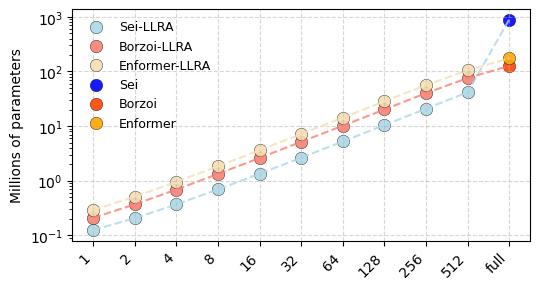

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt

seilora_sizes_file = "seilora_params_sizes.txt"
borzoi_sizes_file = "benchmark_borzoi_model_sizes.tsv"
enformer_sizes_file = "benchmark_enformer_model_sizes.tsv"

# metric to average across the 7 datasets
metric_key = "OvU"  

def read_size_file(path, sei=False):
    """Reads model size files and returns {model_name: size} dict"""
    if sei:
        df_sizes = pd.read_csv(path, sep="\t", header=None)
        rank_col, size_col = df_sizes.columns[:2]
        return {f"seilora_{r}_None_no_quant": float(s)
                for r, s in zip(df_sizes[rank_col], df_sizes[size_col])}
    else:
        df_sizes = pd.read_csv(path, sep="\t", header=0)
        model_col, rank_col, size_col = df_sizes.columns[0], df_sizes.columns[1], df_sizes.columns[4]
        return {f"{m}_lora_lr{r}_crfull_None_no_quant": float(s)
                for m, r, s in zip(df_sizes[model_col], df_sizes[rank_col], df_sizes[size_col])}

# ------------------------------
# Load size data
# ------------------------------
size_lookup = {}
for path in [borzoi_sizes_file, enformer_sizes_file]:
    try:
        size_lookup.update(read_size_file(path))
    except Exception as e:
        print("Warning:", e)

try:
    size_lookup.update(read_size_file(seilora_sizes_file, sei=True))
except Exception as e:
    print("Warning:", e)

# ------------------------------
# Build plot data
# ------------------------------
points = {
    "Sei-LLRA": [], "Borzoi-LLRA": [], "Enformer-LLRA": [],
    "Sei": [], "Borzoi": [], "Enformer": []
}
group_colors = {
    "Sei-LLRA": "lightblue", "Borzoi-LLRA": "salmon", "Enformer-LLRA": "wheat",
    "Sei": "blue", "Borzoi": "orangered", "Enformer": "orange"
}

# extract rank numbers from model names and pair with sizes
for name, size in size_lookup.items():
    if "seilora" in name.lower():
        base, full = "Sei-LLRA", "Sei"
    elif "borzoi" in name.lower():
        base, full = "Borzoi-LLRA", "Borzoi"
    elif "enformer" in name.lower():
        base, full = "Enformer-LLRA", "Enformer"
    else:
        continue

    if "lrfull" in name.lower() or "seilora_full" in name.lower():
        points[full].append(("full", size / 1e6))
    else:
        m = re.search(r"(\d+)", name)
        if m:
            rank = int(m.group(1))
            points[base].append((rank, size / 1e6))

# ------------------------------
# Plot
# ------------------------------
fig, ax = plt.subplots(figsize=(5.5, 3))

# get unique rank categories
numeric_ranks = sorted({r for pts in points.values() for r, _ in pts if str(r).isdigit()})
cats = [str(x) for x in numeric_ranks] + ["full"]
idx_map = {cat: i for i, cat in enumerate(cats)}

# scatter points
for group_label, pts in points.items():
    if not pts:
        continue
    xs = [idx_map.get(str(r), len(cats)-1) for r, _ in pts]
    ys = [y for _, y in pts]
    color = group_colors.get(group_label, "gray")
    ax.scatter(xs, ys, s=80, color=color, edgecolor="k",
               alpha=0.9, linewidth=0.3, label=group_label)

# connect LoRA series
for lora_label, full_label in [
    ("Sei-LLRA", "Sei"),
    ("Borzoi-LLRA", "Borzoi"),
    ("Enformer-LLRA", "Enformer")
]:
    lora_pts = points.get(lora_label, [])
    full_pts = points.get(full_label, [])

    if lora_pts:
        # Sort LoRA points by rank
        lora_pts_sorted = sorted(lora_pts, key=lambda x: int(x[0]))

        # Append full model point if available
        if full_pts:
            full_rank = "full"
            full_y = full_pts[0][1]
            lora_pts_sorted.append((full_rank, full_y))

        # Convert to numeric indices for plotting
        xs_line = [idx_map[str(r)] for r, _ in lora_pts_sorted]
        ys_line = [y for _, y in lora_pts_sorted]

        # Plot line
        ax.plot(
            xs_line, ys_line,
            linestyle="--",
            color=group_colors[lora_label],
            linewidth=1.5,
            alpha=0.8
        )

# aesthetics
ax.set_xticks(range(len(cats)))
ax.set_xticklabels(cats, rotation=45, ha="right")
ax.set_xlabel("", fontsize=10)
ax.set_yscale("log")
ax.set_ylabel("Millions of parameters", fontsize=10)
# ax.set_title("Model rank vs number of parameters", fontsize=13)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig("../figs/fig1_rank_vs_params.png", dpi=300)
plt.show()


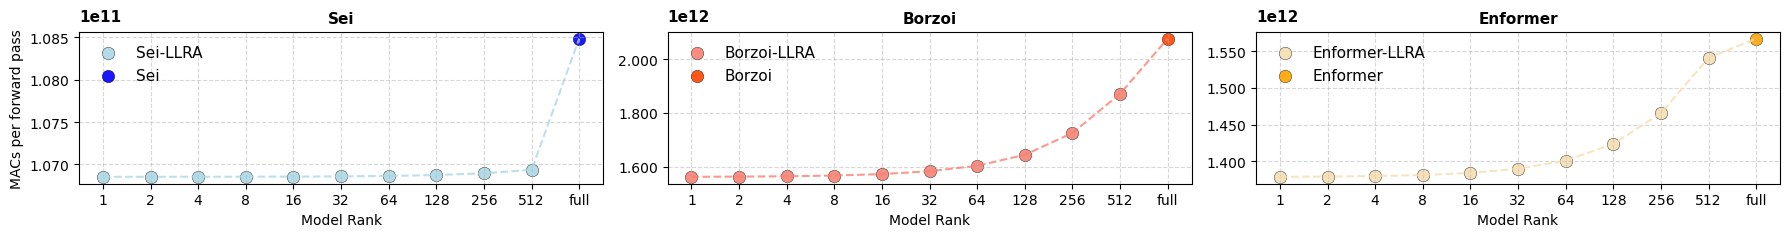

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mticker

group_colors = {
    "Sei-LLRA": "lightblue", "Borzoi-LLRA": "salmon", "Enformer-LLRA": "wheat",
    "Sei": "blue", "Borzoi": "orangered", "Enformer": "orange"
}

flop_files = {
    "Sei-LLRA": "sei_flops.tsv",
    "Borzoi-LLRA": "borzoi_flops.tsv",
    "Enformer-LLRA": "enformer_flops.tsv",
}

# Read data
points_flops = {label: [] for label in ["Sei-LLRA", "Borzoi-LLRA", "Enformer-LLRA", "Sei", "Borzoi", "Enformer"]}

for label, path in flop_files.items():
    try:
        df_flop = pd.read_csv(path, sep="\t", header=None, names=["rank", "flops"])
        for r, f in zip(df_flop["rank"], df_flop["flops"]):
            base_label = label.replace("-LLRA", "") if str(r).lower() == "full" else label
            points_flops[base_label].append((r, float(f)))
    except Exception as e:
        print(f"Warning: couldn't process {path}: {e}")

# Build categorical rank order
ranks_all = sorted({int(r) for pts in points_flops.values() for r, _ in pts if str(r).isdigit()})
cats_flops = [str(x) for x in ranks_all]
if "full" not in cats_flops:
    cats_flops.append("full")
idx_map_flops = {cat: i for i, cat in enumerate(cats_flops)}

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(18, 2.5), sharey=False)
model_pairs = [("Sei", "Sei-LLRA"), ("Borzoi", "Borzoi-LLRA"), ("Enformer", "Enformer-LLRA")]

for idx, (full_label, lora_label) in enumerate(model_pairs):
    ax = axes[idx]
    
    # Extract points for both LoRA and full
    for group_label in [lora_label, full_label]:
        pts = points_flops.get(group_label, [])
        if not pts:
            continue
        xs = [idx_map_flops.get(str(r), len(cats_flops) - 1) for r, _ in pts]
        ys = [y for _, y in pts]
        color = group_colors.get(group_label, "gray")
        ax.scatter(xs, ys, color=color, s=80, label=group_label, alpha=0.9, edgecolor='k', linewidth=0.3)
    
    # Connect LoRA → Full
    lora_pts = points_flops.get(lora_label, [])
    full_pts = points_flops.get(full_label, [])
    
    if lora_pts:
        lora_pts_sorted = sorted([p for p in lora_pts if str(p[0]).isdigit()], key=lambda x: int(x[0]))
        if full_pts:
            lora_pts_sorted.append(("full", full_pts[0][1]))
        xs_line = [idx_map_flops[str(r)] for r, _ in lora_pts_sorted]
        ys_line = [y for _, y in lora_pts_sorted]
        ax.plot(xs_line, ys_line, linestyle="--", color=group_colors[lora_label], linewidth=1.5, alpha=0.8)
    
    # Y-axis settings
    ys_all = [y for _, y in points_flops.get(full_label, []) + points_flops.get(lora_label, [])]
    if ys_all:
        max_val = max(ys_all)
        exponent = int(np.floor(np.log10(max_val)))
        
        # Format ticks - divide by 10^exponent for cleaner display
        def make_formatter(exp):
            def formatter(y, _):
                if y <= 0:
                    return "0"
                return f"{y / 10**exp:.3f}"
            return formatter
        
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(make_formatter(exponent)))
        
        # Add order-of-magnitude label above grid
        ax.text(0, 1.05, f"1e{exponent}", transform=ax.transAxes,
                fontsize=11, fontweight='bold', va='bottom', ha='left')
    
    # Aesthetics
    if idx == 0:
        ax.set_ylabel("MACs per forward pass", fontsize=10)
    
    ax.set_title(full_label, fontsize=11, fontweight='bold')
    ax.legend(frameon=False, fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.5)
    
    # X-axis
    ax.set_xlabel("Model Rank", fontsize=10)
    ax.set_xticks(list(range(len(cats_flops))))
    ax.set_xticklabels(cats_flops, rotation=0, ha="center")

plt.tight_layout()
plt.savefig("../figs/fig1_flops_vs_rank_row.png", dpi=300)
plt.show()

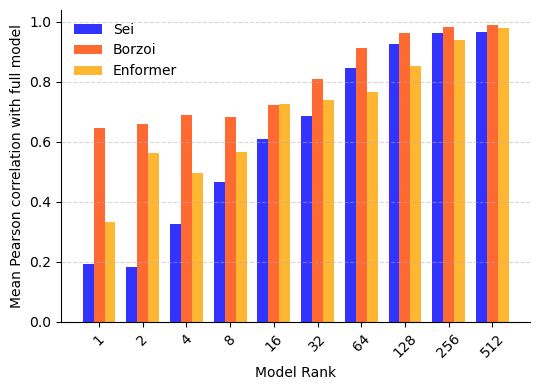

In [6]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# --- Load correlation data ---
with open("borzoi_pearson_corrs_shuffle.pkl", "rb") as f:
    borzoi_corrs = pickle.load(f)
with open("enformer_pearson_corrs_shuffle.pkl", "rb") as f:
    enformer_corrs = pickle.load(f)
with open("sei_pearson_corrs_shuffle.pkl", "rb") as f:
    sei_corrs = pickle.load(f)

# --- Compute mean correlations per rank ---
ranks = sorted(list(borzoi_corrs.keys()))
borzoi_means = [np.mean(borzoi_corrs[r]) for r in ranks]
enformer_means = [np.mean(enformer_corrs[r]) for r in ranks]
sei_means = [np.mean(sei_corrs[r]) for r in ranks]

# --- Plot setup ---
x = np.arange(len(ranks))
width = 0.25  # bar width

colors = {
    "borzoi": "orangered",    # reddish orange
    "enformer": "orange",  # golden yellow
    "sei": "blue",       # blue
}

fig, ax = plt.subplots(figsize=(5.5, 4))

# --- Bar plots ---
ax.bar(x - width, sei_means, width, color=colors["sei"], alpha=0.8, label="Sei")
ax.bar(x, borzoi_means, width, color=colors["borzoi"], alpha=0.8, label="Borzoi")
ax.bar(x + width, enformer_means, width, color=colors["enformer"], alpha=0.8, label="Enformer")

# --- Formatting ---
ax.set_xticks(x)
ax.set_xticklabels(ranks, rotation=45)
ax.set_xlabel("Model Rank")
ax.set_ylabel("Mean Pearson correlation with full model")
ax.legend(frameon=False)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../figs/fig1_pearson_vs_rank_barplot_shuffled.png", dpi=300)
plt.show()
